In [12]:
from mGST.visualization import plot_alternating_optimization, plot_cost_function

In [5]:
cost_fn_history_all_tr = [
    8.497723e-04, 8.173345e-04, 7.855616e-04, 7.740607e-04, 7.739345e-04, 7.739239e-04, 7.738533e-04, 7.738533e-04, 7.550035e-04, 6.786121e-04,
    6.786121e-04, 5.710481e-04, 4.676108e-04, 3.962855e-04, 3.833166e-04, 3.792876e-04, 3.772592e-04, 3.760811e-04, 3.753286e-04, 3.748008e-04,
    3.744100e-04, 3.722551e-04, 3.722536e-04, 3.722536e-04, 3.722536e-04, 3.722535e-04, 3.722534e-04, 3.722532e-04, 3.722528e-04, 3.722519e-04,
    3.722500e-04, 3.509813e-04, 3.228772e-04, 3.054634e-04, 2.827571e-04, 2.827571e-04, 2.754875e-04, 2.730398e-04, 2.643500e-04, 2.568273e-04, 
    2.568273e-04, 2.474592e-04
]

data_operator_map = [
    ("povm", 10), ("kraus", 10), ("state", 10), ("povm", 10), ("kraus", 1)
] # assume the first data point is the un-optimized one

# length of the sequences defined by data operator map
length_of_sequences = sum([length for _, length in data_operator_map])

print("Length of sequences:", length_of_sequences)
print(len(cost_fn_history_all_tr))

Length of sequences: 41
42


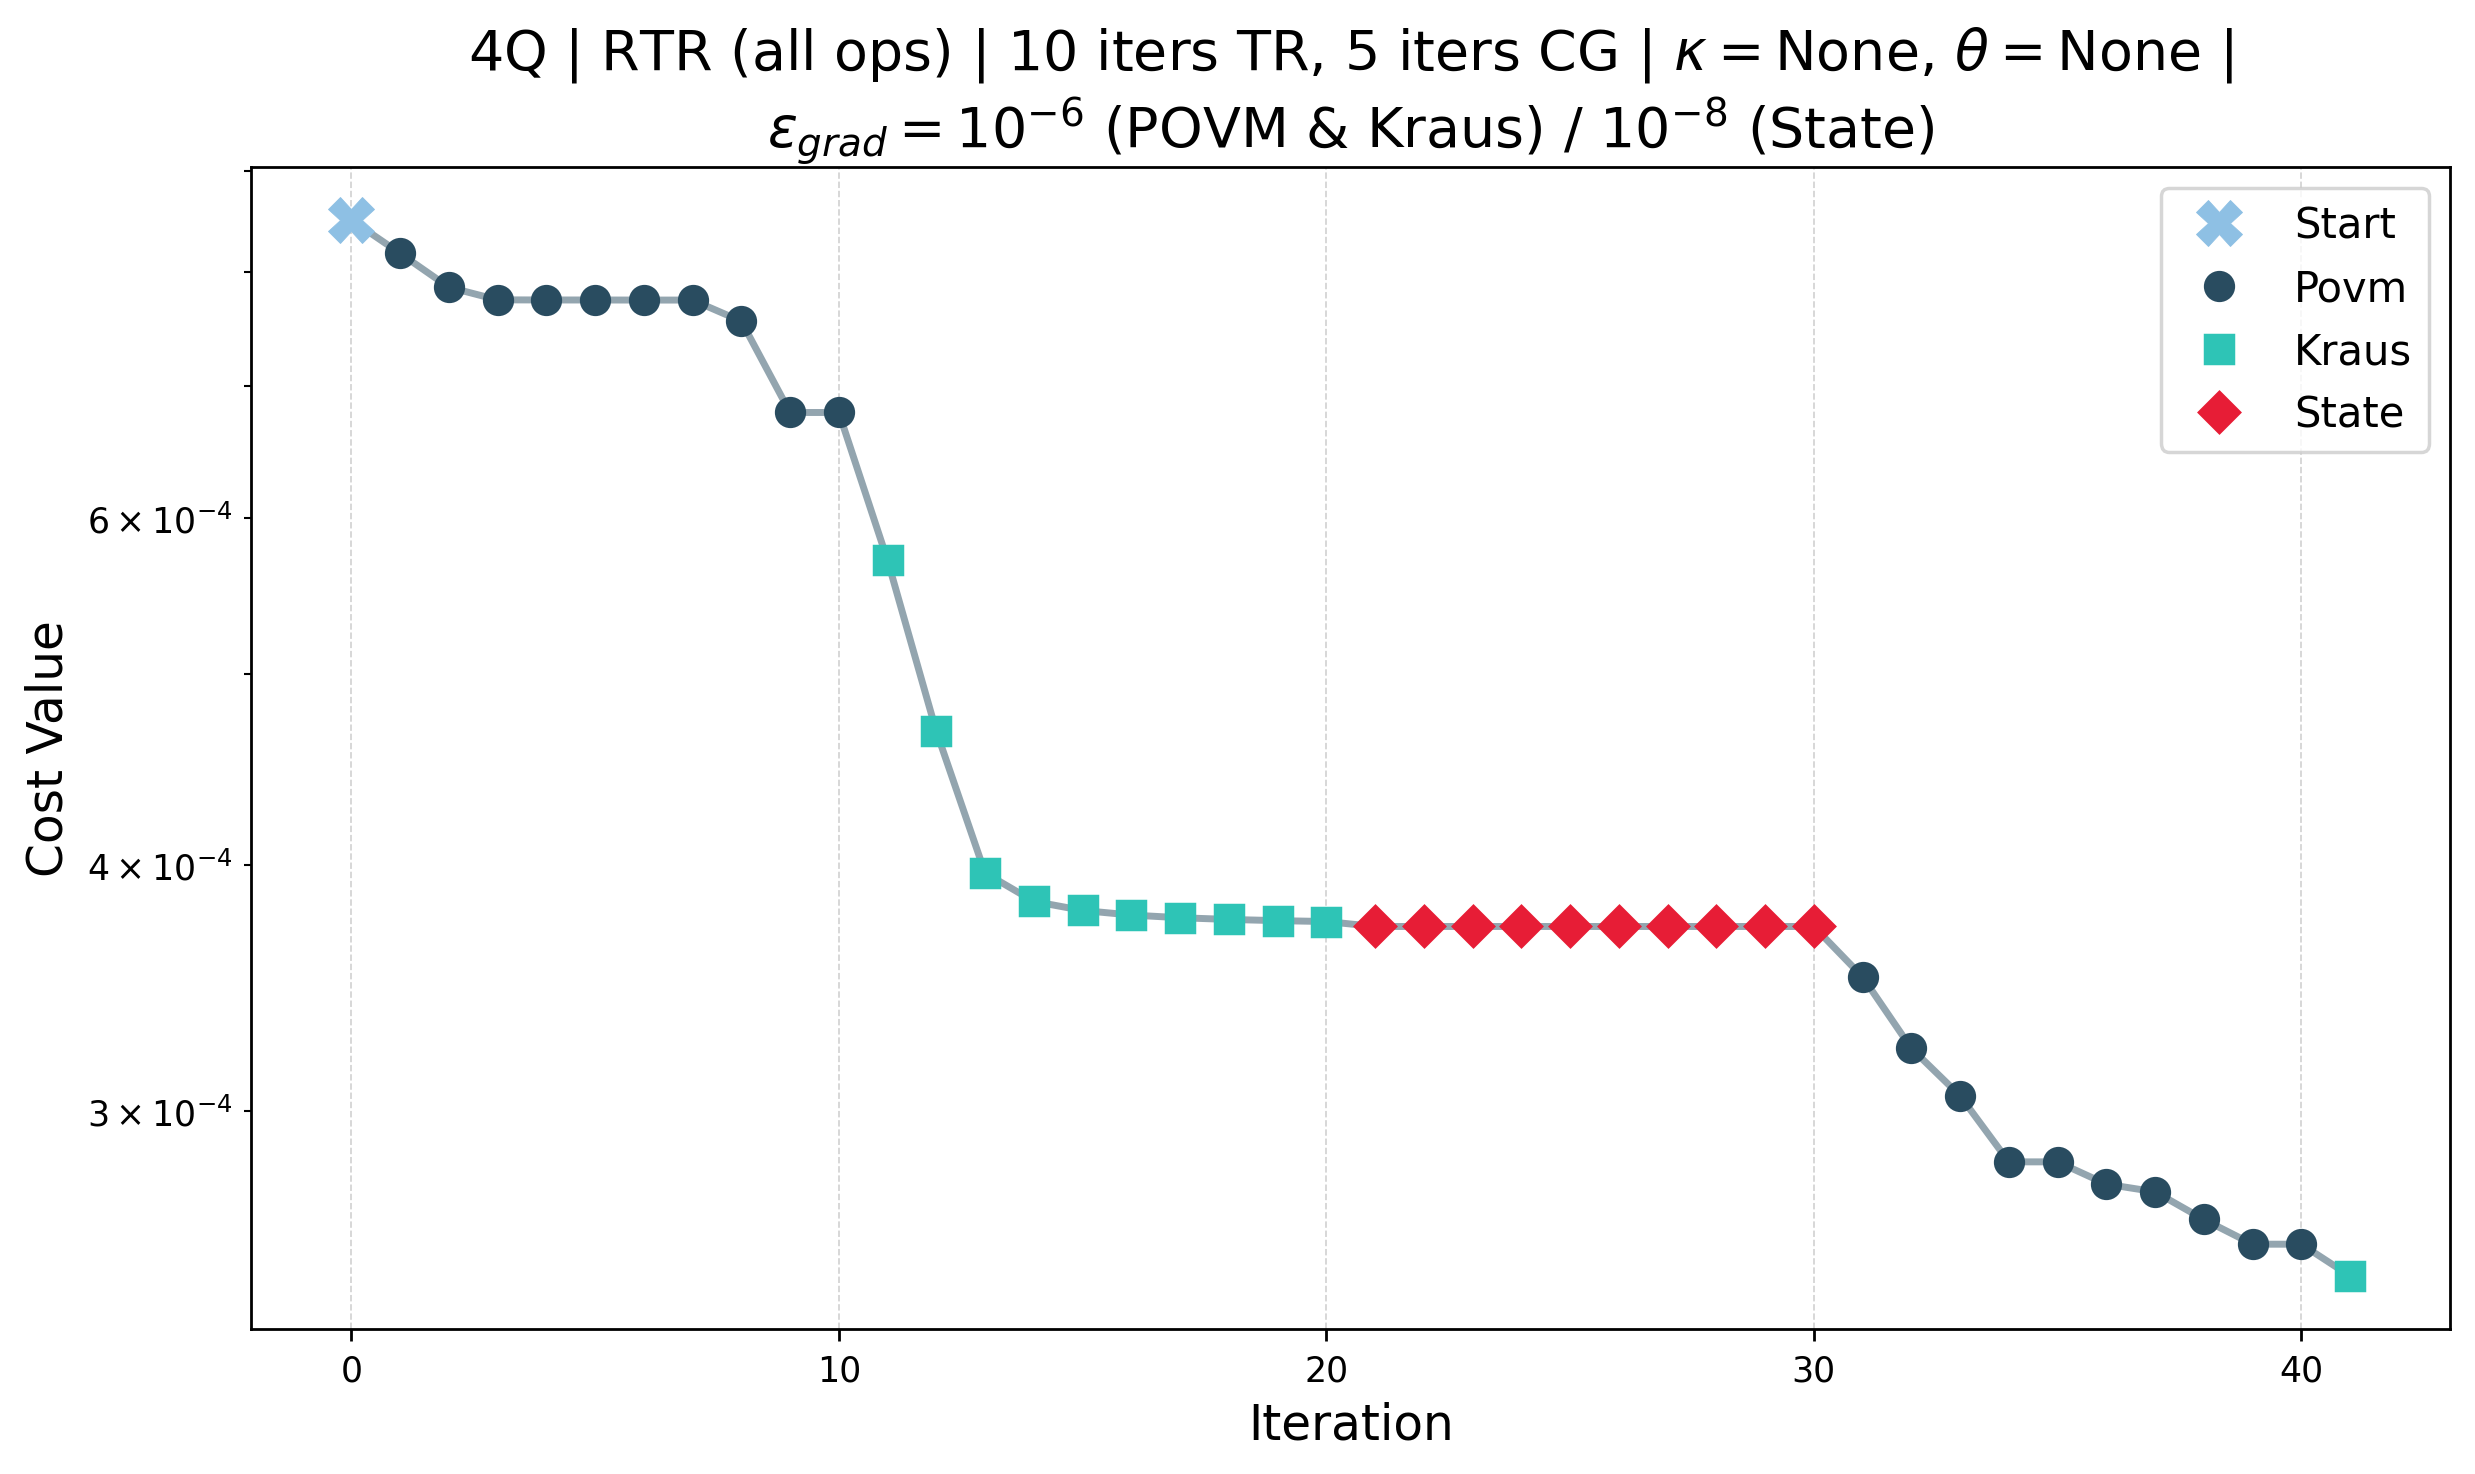

In [22]:

plot_alternating_optimization(
    cost_array=cost_fn_history_all_tr,
    data_operator_map=data_operator_map,
    title=r"4Q | RTR (all ops) | 10 iters TR, 5 iters CG | $\kappa = $None, $\theta = $None | $\epsilon_{grad} = 10^{-6}$ (POVM & Kraus) / $10^{-8}$ (State)"
)

In [ ]:
povm_1 = [5.936455e-04, 5.744546e-04, 5.744546e-04, 5.725827e-04, 5.723656e-04, 5.718676e-04, 5.696367e-04, 5.585092e-04, 5.284677e-04, 4.568979e-04]

kraus_1 = [3.920637e-04, 3.427012e-04, 2.931688e-04, 2.931688e-04, 2.609816e-04, 2.331235e-04, 1.916005e-04, 1.916005e-04, 1.781652e-04, 1.626076e-04]

state_1 = [1.614913e-04, 1.614913e-04]

povm_2 = [1.517099e-04, 1.453114e-04, 1.453114e-04, 1.439467e-04, 1.439467e-04, 1.435979e-04, 1.435207e-04, 1.432458e-04, 1.429516e-04, 1.428190e-04]

kraus_2 = [1.352857e-04, 1.300021e-04, 1.219712e-04, 1.167075e-04, 1.142538e-04, 1.127620e-04, 1.117286e-04, 1.109790e-04, 1.104099e-04,1.099706e-04]

cost_fn_history_rank_4 = [6.194426e-04]
cost_fn_history_rank_4.extend(povm_1)
cost_fn_history_rank_4.extend(kraus_1)
cost_fn_history_rank_4.extend(state_1)
cost_fn_history_rank_4.extend(povm_2)
cost_fn_history_rank_4.extend(kraus_2)

data_operator_map_rank_4 = [
    ("povm", len(povm_1)), ("kraus", len(kraus_1)), ("state", len(state_1)),
    ("povm", len(povm_2)), ("kraus", len(kraus_2))
]

# length of the sequences defined by data operator map
length_of_sequences_rank_4 = sum([length for _, length in data_operator_map_rank_4])

print("Length of sequences:", length_of_sequences_rank_4)
print(len(cost_fn_history_rank_4))

Length of sequences: 41
42


In [46]:
data_operator_map_rank_4

[('povm', 10), ('kraus', 10), ('state', 2), ('povm', 10), ('kraus', 9)]

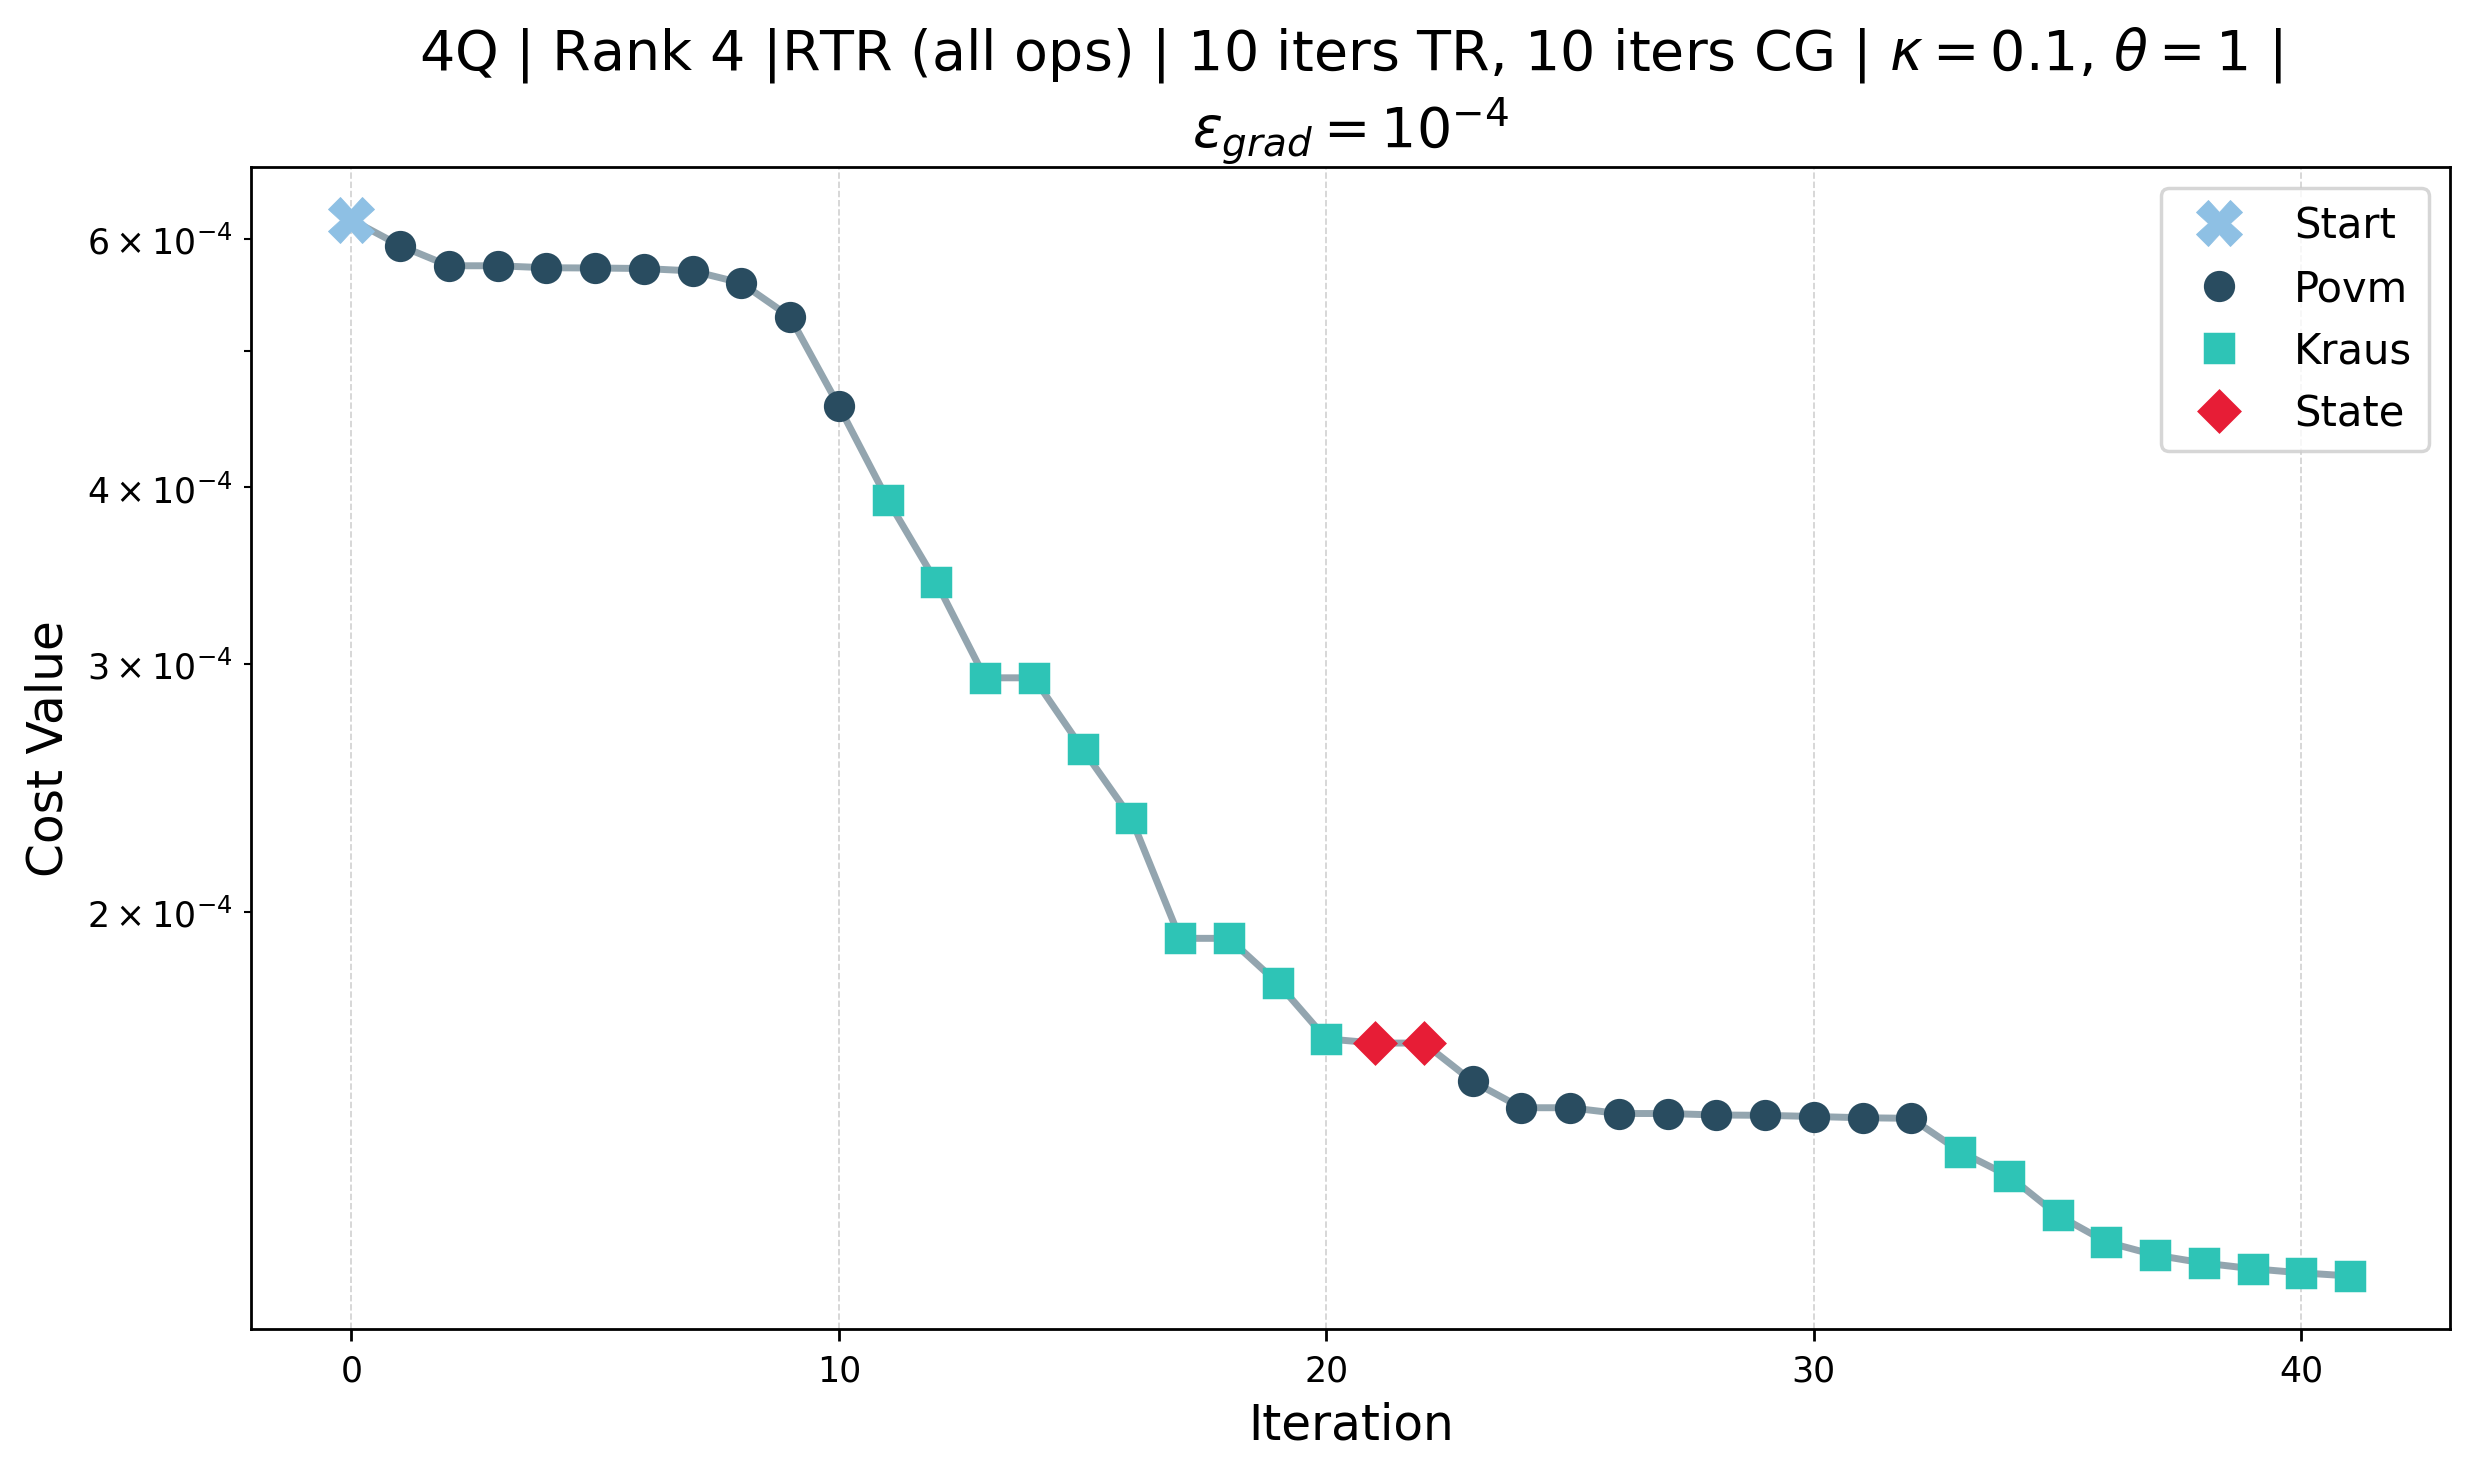

In [44]:
plot_alternating_optimization(
    cost_array=cost_fn_history_rank_4,
    data_operator_map=data_operator_map_rank_4,
    title=r"4Q | Rank 4 |RTR (all ops) | 10 iters TR, 10 iters CG | $\kappa = 0.1$, $\theta = 1$ | $\epsilon_{grad} = 10^{-4}$"
)

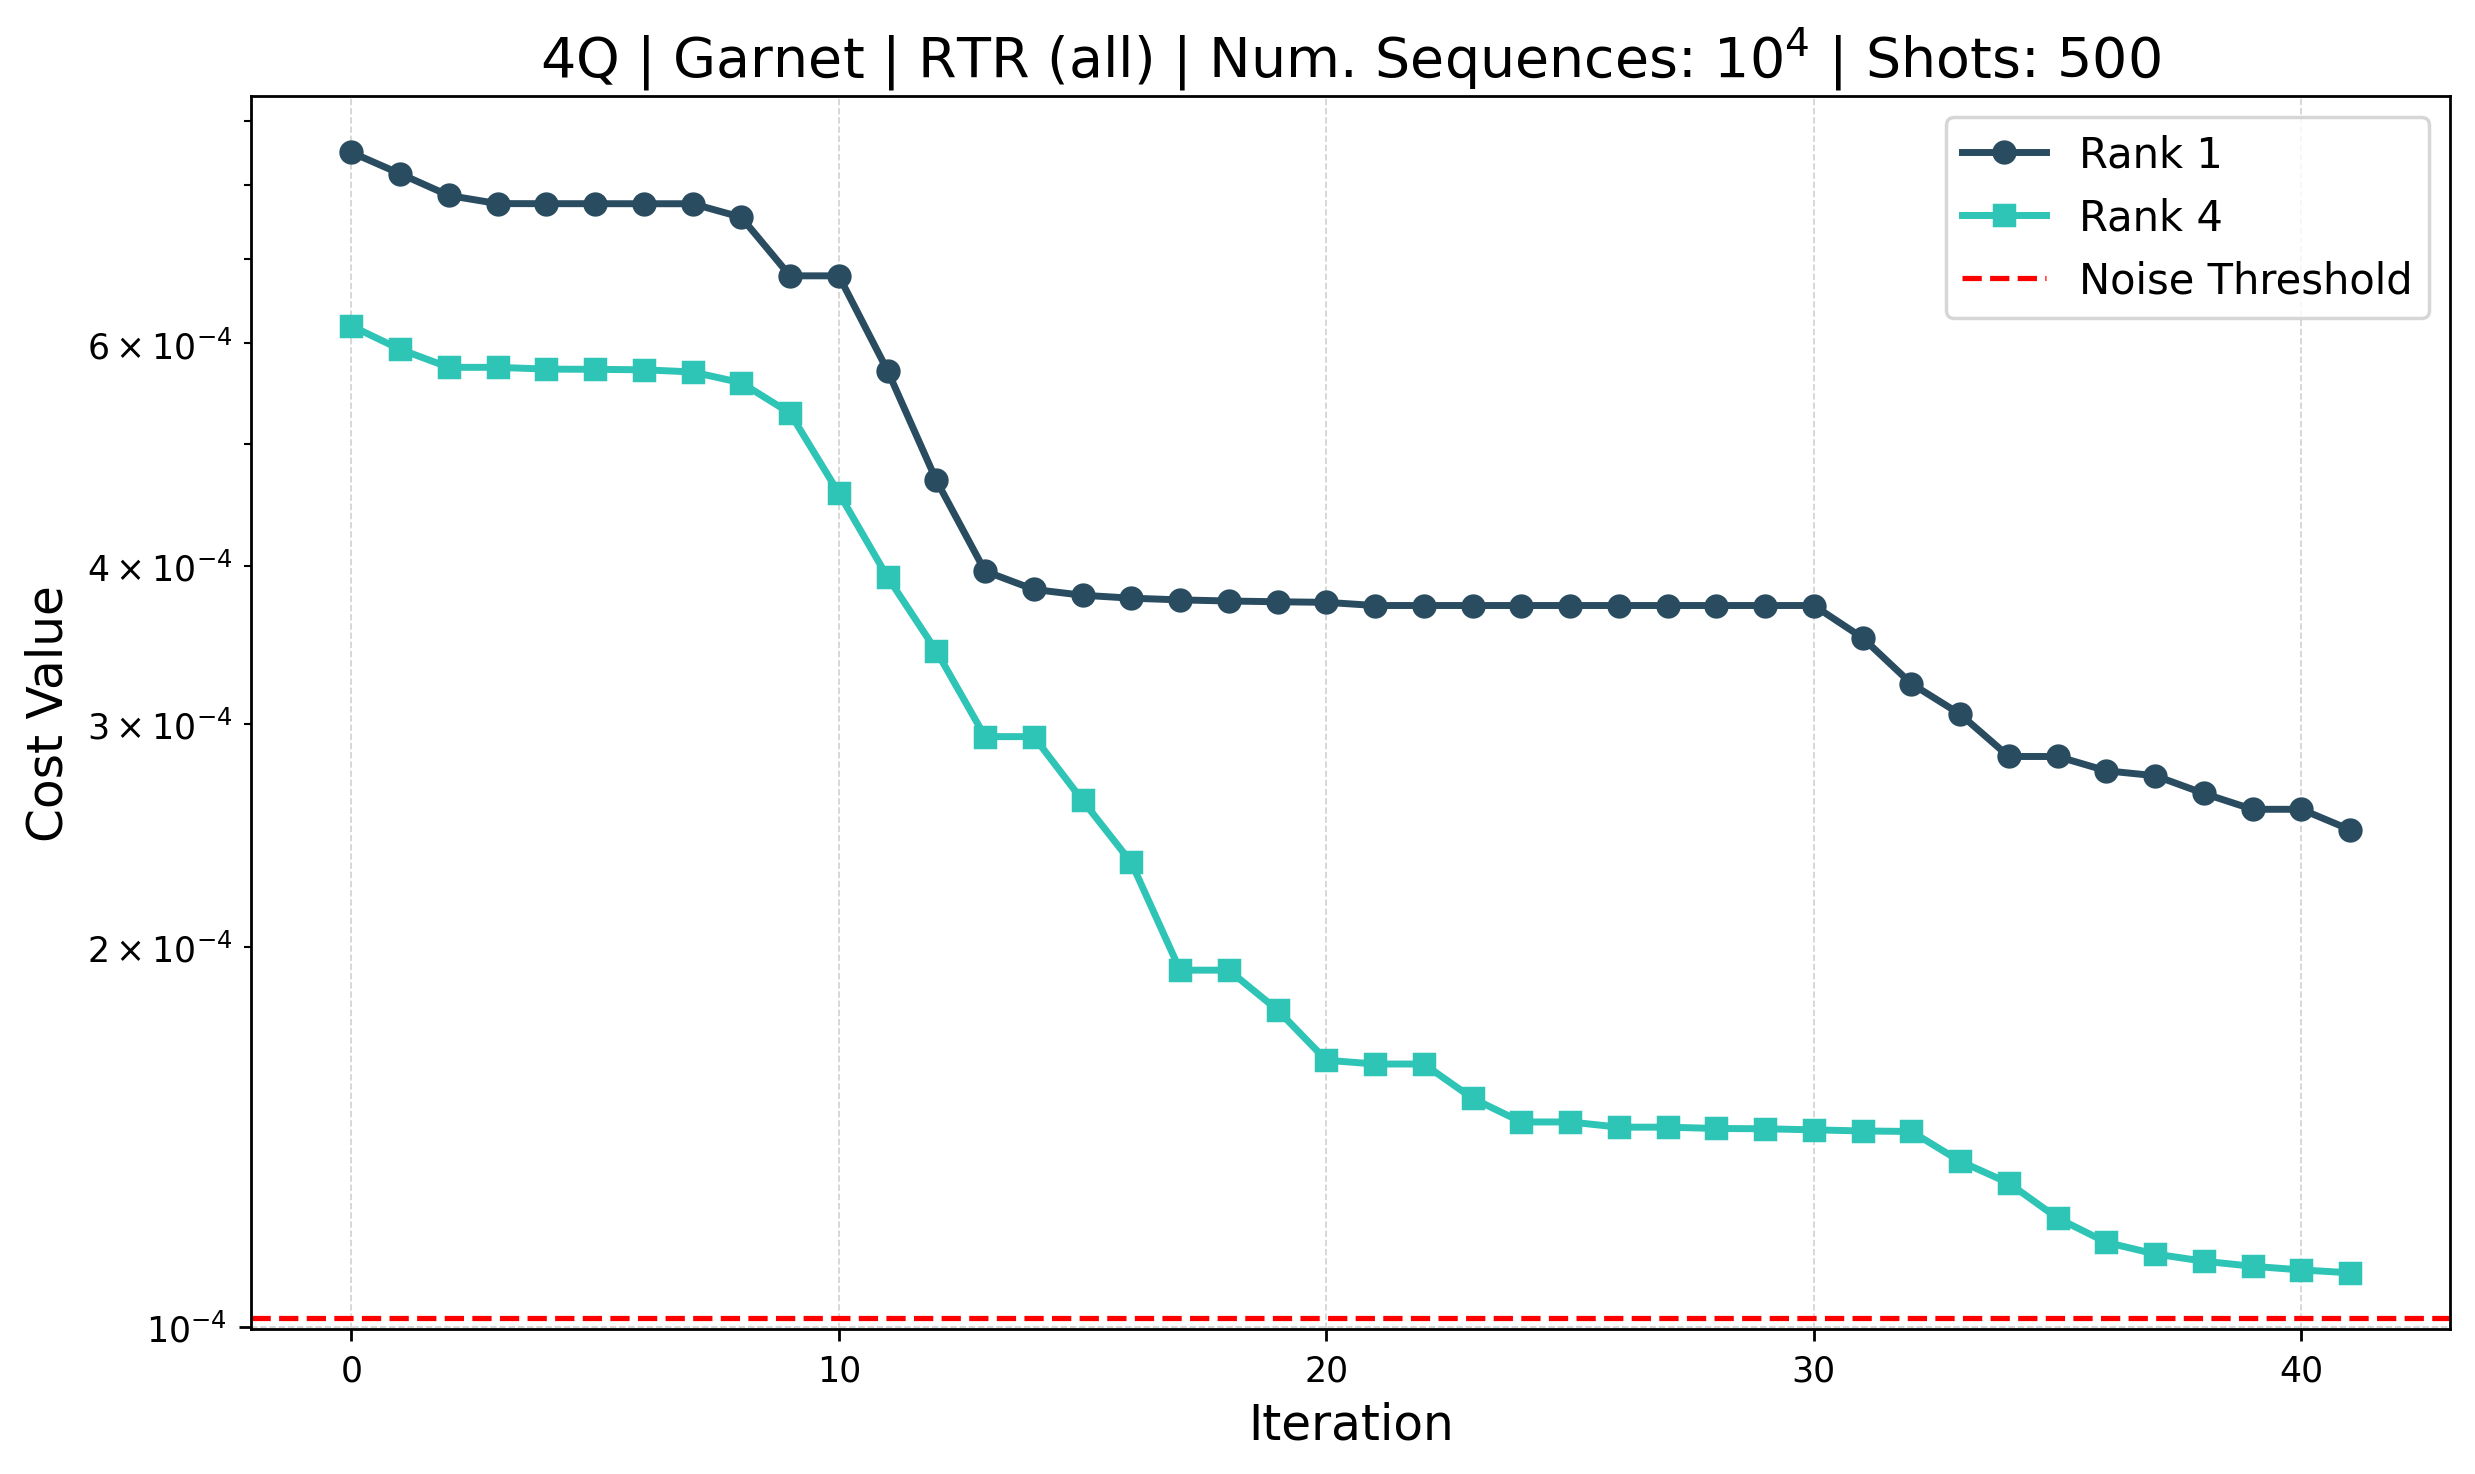

In [45]:
noise_threshold = 0.0001016521870999998

plot_cost_function(
    cost_array=[cost_fn_history_all_tr, cost_fn_history_rank_4],
    labels=[r"Rank 1", r"Rank 4"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title=f"4Q | Garnet | RTR (all) | Num. Sequences: $10^4$ | Shots: 500"
)